##Model Development/ Cross_validation/ Pipeline / Evaluation

**Objectives**
1. Use Linear Regression in one variable to fit the parameters to a model
2. Use Linear Regression in multiple variables to fit the parameters to a model
3. Use Polynomial Regression in single variable tofit the parameters to a model
4. Create a pipeline for performing linear regression using multiple features in polynomial scaling
5. Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters

**Install Required Libraries**

`pandas` for managing the data.
`numpy` for mathematical operations.
`sklearn` for machine learning and machine-learning-pipeline related functions.
`seaborn` for visualizing the data.
`matplotlib` for additional plotting tools.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
#mount the drive to upload the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Quick doublecheck Preprocessing and EDA

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/clean_laptop_data.csv")

In [ ]:
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight,Price,IPS,Touchscreen,Full_HD,HD_1920,Price-binned
0,HP,3,2,0,7,15.6,2.7,6,256,2.04,5148468,0,0,0,0,Low
1,Asus,1,3,0,7,17.3,2.8,16,256,2.99,15552108,0,0,1,1,Low
2,Dell,3,2,0,7,15.6,2.7,12,512,2.19,11550708,1,1,1,1,Low
3,Toshiba,3,2,0,5,13.3,2.3,4,128,1.20,10625940,0,0,1,1,Low
4,Lenovo,3,1,0,5,15.6,3.6,6,256,2.20,4881708,0,0,1,1,Low


In [ ]:
df.dtypes

,0
Manufacturer,object
Category,int64
GPU,int64
OS,int64
CPU_core,int64
Screen_Size_inch,float64
CPU_frequency,float64
RAM_GB,int64
Storage_GB_SSD,int64
Weight,float64


In [ ]:
df.describe()

,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight,Price,IPS,Touchscreen,Full_HD,HD_1920
count,1302.000000,1302.000000,1302.000000,1302.000000,1302.000000,1302.000000,1302.000000,1302.000000,1302.000000,1.302000e+03,1302.000000,1302.000000,1302.000000,1302.000000
mean,2.860983,2.166667,0.215822,5.599078,15.016743,2.298464,8.376344,263.112903,2.038533,9.987213e+06,0.280338,0.146697,0.647465,0.645929
std,0.932725,0.648319,0.648035,1.294676,1.426761,0.506413,5.082229,98.521789,0.665691,6.215746e+06,0.449337,0.353940,0.477943,0.478414
min,1.000000,0.000000,0.000000,3.000000,10.100000,0.900000,2.000000,1.000000,0.690000,1.547208e+06,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,0.000000,5.000000,14.000000,2.000000,4.000000,256.000000,1.500000,5.326308e+06,0.000000,0.000000,0.000000,0.000000
50%,3.000000,2.000000,0.000000,5.000000,15.600000,2.500000,8.000000,256.000000,2.040000,8.687484e+06,0.000000,0.000000,1.000000,1.000000
75%,3.000000,3.000000,0.000000,7.000000,15.600000,2.700000,8.000000,256.000000,2.300000,1.321198e+07,1.000000,0.000000,1.000000,1.000000
max,5.000000,3.000000,5.000000,7.000000,18.400000,3.600000,64.000000,512.000000,4.700000,5.423231e+07,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.corr(numeric_only=True)["Price"].sort_values()

,Price
OS,-0.256398
Category,-0.102286
Screen_Size_inch,0.067922
Touchscreen,0.189931
HD_1920,0.194144
Full_HD,0.199829
Weight,0.210166
IPS,0.252799
GPU,0.355304
Storage_GB_SSD,0.361297


Text(0.5, 1.0, 'Effect on Price W.r.t. Operating System')

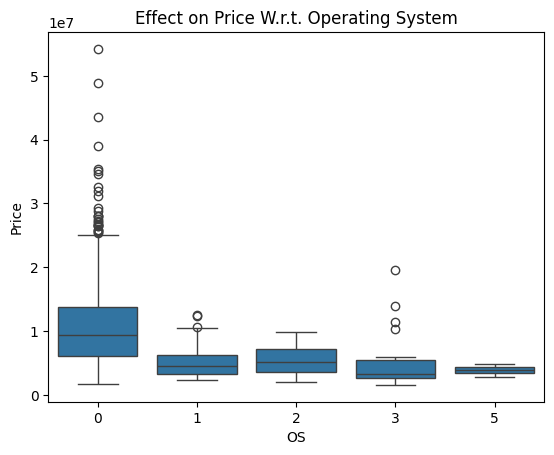

In [ ]:
sns.boxplot(x="OS", y="Price", data=df)
plt.title('Effect on Price W.r.t. Operating System')

OS = 0 shows the highest price variation and many high-value outliers, indicating premium laptops are concentrated in this category.
Other OS categories have lower and more stable price distributions, suggesting OS has an impact but is not the strongest price driver alone.

Text(0.5, 1.0, 'GPU W.r.t. Price')

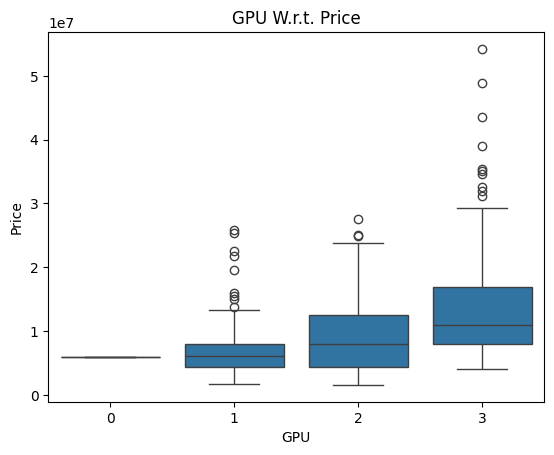

In [ ]:
sns.boxplot(x="GPU", y="Price", data=df)
plt.title('GPU W.r.t. Price')

Higher GPU categories tend to have higher median prices, with noticeable variation and outliers, indicating GPU also significantly impacts pricing but not in a perfectly linear way.

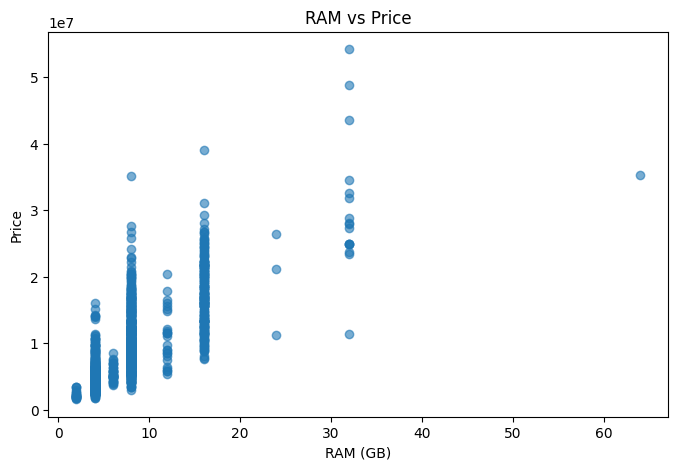

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["RAM_GB"], df["Price"], alpha=0.6)

plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.title("RAM vs Price")

plt.show()

There is a clear positive trend — as RAM increases, laptop price generally increases, showing RAM is a strong predictor of price. However, there is some spread, meaning other features also influence price.

###Single Linear Regression

First, Do it with the best feature

In [ ]:
X = df[["RAM_GB"]]
y = df["Price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

slr = LinearRegression()
slr.fit(X_train, y_train)

LinearRegression()

slr= single linear regression

In [ ]:
y_pred = slr.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.5468010979689395
MSE: 13931894933715.31


A simple linear regression model was developed using RAM_GB as the only independent variable to predict laptop Price. The model achieved an R² score of 0.5468, indicating that approximately 54.68% of the variation in price can be explained by RAM alone, with an MSE of 13.93 trillion.

Text(0, 0.5, 'RAM_GB')

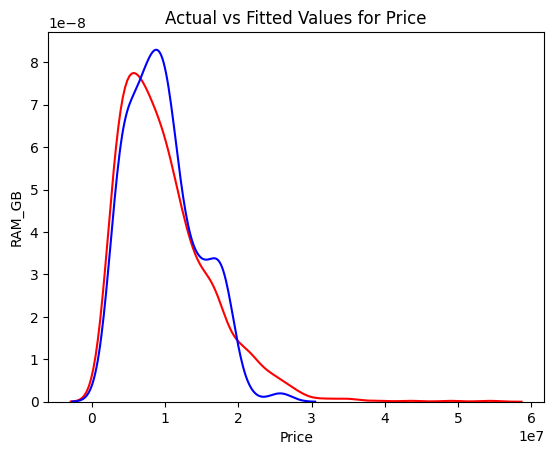

In [ ]:
ax1 = sns.kdeplot(df['Price'], color="r", label="Actual Value")
sns.kdeplot(y_pred, color="b", label="Fitted Values", ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('RAM_GB')

###Multiple Linear Regression

In [ ]:
# Step 1: Multiple Features and target
x1 = df[["RAM_GB", "CPU_core", "CPU_frequency"]]
y1 = df["Price"]

# Step 2: Train-test split
from sklearn.model_selection import train_test_split

x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1,
    test_size=0.2,
    random_state=42
)

# Step 3: Train model
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(x1_train, y1_train)

# Step 4: Predict
y_pred1 = model1.predict(x1_test)

# Step 5: Evaluate
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y1_test, y_pred1))
print("MSE:", mean_squared_error(y1_test, y_pred1))

R2 Score: 0.5687622117590387
MSE: 13256783126118.61


A multiple linear regression model was created using RAM_GB, CPU_core, and CPU_frequency as predictor variables. The model showed improved performance with an R² score of 0.5688 and a reduced MSE of 13.26 trillion, demonstrating that combining multiple hardware specifications improves price prediction accuracy.

Text(0, 0.5, 'Proportion of laptops')

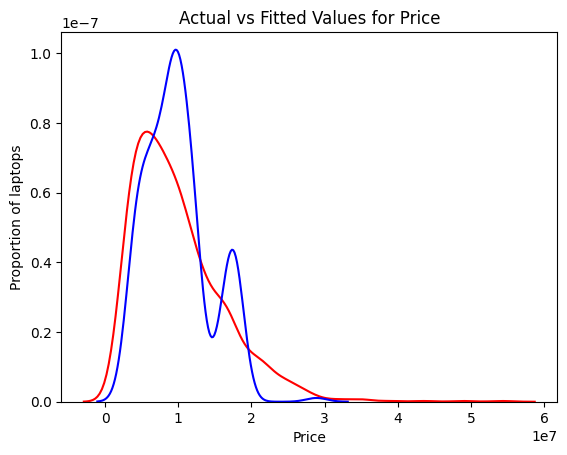

In [ ]:
ax2 = sns.kdeplot(df['Price'], color="r", label="Actual Value")
sns.kdeplot(y_pred1, color="b", label="Fitted Values", ax=ax2)
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')

In [ ]:
#lets do it with adding more features
# Step 1: Features and target
Z = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core', 'GPU']]
y2 = df['Price']

# Step 2: Train-test split
from sklearn.model_selection import train_test_split

Z_train, Z_test, y2_train, y2_test = train_test_split(
    Z, y2,
    test_size=0.2,
    random_state=42
)

# Step 3: Train Linear Regression model
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(Z_train, y2_train)

# Step 4: Prediction
Y_pred2 = model2.predict(Z_test)

# Step 5: Evaluation
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y2_test, Y_pred2))
print("MSE:", mean_squared_error(y2_test, Y_pred2))

R2 Score: 0.5725440827708145
MSE: 13140523732389.295


Text(0, 0.5, 'Proportion of laptops')

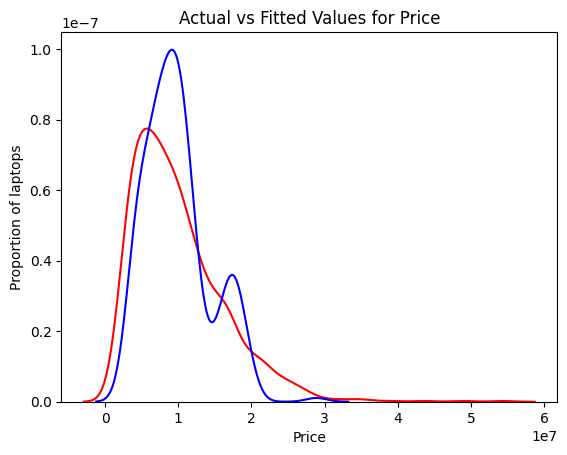

In [ ]:
ax3 = sns.kdeplot(df['Price'], color="r", label="Actual Value")
sns.kdeplot(Y_pred2, color="b", label="Fitted Values" , ax=ax3)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')

###Polynomial Regression

Polynomial Regression
Use the variable "RAM_GB "to create Polynomial features for 3 different values of polynomial degrees.

In [ ]:
#olynomial Regression (Single Variable) Using RAM_GB as the predictor:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[['RAM_GB']]
y = df['Price']

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

In [ ]:
#Evaluate the model
from sklearn.metrics import r2_score, mean_squared_error

print("R²:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))

R²: 0.5733363175474446
MSE: 16471702704167.533


Polynomial regression was applied using RAM_GB as the single predictor to capture possible non-linear relationships with Price. The model achieved an R² score of 0.5733, slightly higher than the simple linear regression model, but produced a higher MSE of 16.47 trillion, indicating larger prediction errors despite the improved fit.

Pipeline for Polynomial Regression with Multiple Features

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[['RAM_GB',
        'CPU_core',
        'CPU_frequency',
        'Storage_GB_SSD',
        'GPU']]

y = df['Price']

pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

pipe.fit(X, y)

y_pred = pipe.predict(X)

In [ ]:
#Evaluate the Model
from sklearn.metrics import r2_score, mean_squared_error

print("R²:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))

R²: 0.6538942401910195
MSE: 13361697782673.318


A machine learning pipeline combining Polynomial Features and Linear Regression was implemented using RAM_GB, CPU_core, CPU_frequency, Storage_GB_SSD, and GPU. This model achieved the highest R² score of 0.6539, explaining approximately 65.39% of the variation in laptop prices. The MSE was 13.36 trillion, indicating competitive predictive performance while capturing more complex relationships among the features.

###Cross validation
Cross-validation improves this by testing the model on multiple splits of the data.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge


In [ ]:
#Divide the dataset into x_data and y_data parameters. Here y_data is the "Price" attribute, and x_data has all other attributes in the data set.
y_data = df['Price']
x_data = df.drop('Price',axis=1)

In [ ]:
#:Split the data set into training and testing subests such that you reserve 10% of the data set for testing purposes.
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)
print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples : 131
number of training samples: 1171


In [ ]:
#Create a single variable linear regression model using "RAM_GB" parameter. Print the R^2 value of this model for the training and testing subsets.
lre=LinearRegression()
lre.fit(x_train[['RAM_GB']], y_train)
#calculates the R² score on the unseen test data.
print(lre.score(x_test[['RAM_GB']], y_test))
#calculates the R² score on the same data used to train the model
print(lre.score(x_train[['RAM_GB']], y_train))

0.41054029148949855
0.5652123304914844


Training R² = 0.5652: The model explains approximately 56.52% of the variation in laptop prices on the training data.
Testing R² = 0.4105: On unseen test data, the model explains only 41.05% of the variation in laptop prices.The test R² is noticeably lower than the training R².The lower performance on the test data indicates that RAM alone cannot fully explain laptop prices and that additional hardware features are needed to improve prediction accuracy and generalization.

In [ ]:
#Run a 4-fold cross validation on the model and print the mean value of R^2 score along with its standard deviation.
Rcross = cross_val_score(lre, x_train[['RAM_GB']], y_train, cv=4)
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is", Rcross.std())

The mean of the folds are 0.5611479397784094 and the standard deviation is 0.02415656766376312


The model using only RAM_GB achieved an average cross-validated R² score of 0.5611 with a standard deviation of 0.0242, indicating stable performance across different data splits. This confirms that RAM is a moderately strong predictor of laptop price, although it alone cannot fully capture price variability.

###Improved Model (Multiple Variables) most important and useful


In [ ]:
# Model
x = df[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core', 'GPU']]
y = df['Price']
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')

print(cv_scores.mean())

0.5886402646386915


58.86% of the variation in laptop prices. The model has moderate predictive power but needs improvement for high accuracy.

###Ridge Regression with GridSearcCV

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, cross_val_score

# model
ridge = Ridge()

# hyperparameter grid
params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# GridSearch with 5-fold CV
grid = GridSearchCV(ridge, params, cv=5, scoring='r2')

# fit model
grid.fit(x, y)

# best model info
print("Best alpha:", grid.best_params_)
print("Best CV R2 (GridSearch):", grid.best_score_)

Best alpha: {'alpha': 1}
Best CV R2 (GridSearch): 0.588640732302766


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(random_state=42)

rf_scores = cross_val_score(rf, x, y, cv=5, scoring='r2')

print("Random Forest CV R2 Mean:", rf_scores.mean())
print("Random Forest CV R2 Std:", rf_scores.std())

Random Forest CV R2 Mean: 0.6457639603735063
Random Forest CV R2 Std: 0.05901585382750785


In [ ]:
#test_train model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

print("Train R2:", rf.score(x_train, y_train))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.7956636565426478
Test R2: 0.6994923661786512


####Tuned Random Forest

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2')
grid.fit(x, y)

print("Best Params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2: 0.6605363037598359


###GradientBoost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

gbr = GradientBoostingRegressor(random_state=42)

gb_scores = cross_val_score(gbr, x, y, cv=5, scoring='r2')

print("Gradient Boosting CV R2 Mean:", gb_scores.mean())
print("Gradient Boosting CV R2 Std:", gb_scores.std())


Gradient Boosting CV R2 Mean: 0.6643354324603588
Gradient Boosting CV R2 Std: 0.07135637759673148


####Tuned GradiantBoost Regression model (improve performance)

In [ ]:
gbr = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0]
}

from sklearn.model_selection import GridSearchCV

grid_gb = GridSearchCV(gbr, param_grid, cv=5, scoring='r2')

grid_gb.fit(x, y)

print("Best Params:", grid_gb.best_params_)
print("Best CV R2:", grid_gb.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}
Best CV R2: 0.674688639988085


###XGBoost

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

xgb_scores = cross_val_score(xgb, x, y, cv=5, scoring='r2')

print("XGBoost CV R2 Mean:", xgb_scores.mean())
print("XGBoost CV R2 Std:", xgb_scores.std())

XGBoost CV R2 Mean: 0.6325211882591247
XGBoost CV R2 Std: 0.047670936561104355


####Tuned XGBOOST

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb, param_grid, cv=5, scoring='r2')

grid_xgb.fit(x, y)

print("Best Params:", grid_xgb.best_params_)
print("Best CV R2:", grid_xgb.best_score_)

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV R2: 0.670013689994812


In [ ]:
print("Random Forest:", rf_scores.mean())
print("Gradient Boosting:", gb_scores.mean())
print("XGBoost:", xgb_scores.mean())

Random Forest: 0.6457639603735063
Gradient Boosting: 0.6643354324603588
XGBoost: 0.6325211882591247



After applying the above models RidgeRegression/Grid SearchCV/Random Forest/GradientBoost and,XGBOOST,  with cross-validation to systematically tune hyperparameters and identify the best-performing model configuration. This ensured that the final model was not only accurate but also stable and reliable on unseen data.

###Conclusion

Considering all evaluation metrics (R² score, MSE, cross-validation stability, and generalization performance), the**Tuned Gradient Boosting model** is the **most suitable and reliable model** for predicting laptop prices based on hardware specifications.

It achieves the best balance between accuracy and robustness, making it the recommended final model for deployment.